
# Comprehensive Characterization and Python-Based Data Analysis of Iron Oxide Nanoparticles

### A portfolio demonstration of a five-technique materials-characterization workflow

---

> ## ⚠️ SYNTHETIC DATA — PLEASE READ FIRST
>
> **Every dataset in this notebook is synthetic.** It was generated
> computationally by `scripts/generate_synthetic_datasets.py` from explicit
> physical models plus realistic noise.
>
> - No material was synthesized.
> - No instrument was operated.
> - No measurement was performed.
>
> The purpose is to demonstrate **data-analysis and interpretation
> capability** — processing, quantification, statistics and critical reading
> of characterization data. Nothing here is evidence about any real sample,
> and nothing here should be cited as an experimental result.

---

## What this notebook demonstrates

| # | Section | Techniques / methods |
|---|---------|----------------------|
| 1 | Project overview | — |
| 2 | Imports | NumPy, pandas, SciPy, Matplotlib |
| 3 | Dataset loading | provenance-aware CSV loading |
| 4 | XRD | ALS background, pseudo-Voigt fitting, Scherrer, Williamson–Hall, Nelson–Riley |
| 5 | FTIR | baseline correction, Savitzky–Golay, band assignment with confidence grading |
| 6 | UV–Vis | turbidity correction, Tauc analysis *as a cautionary demonstration* |
| 7 | SEM | descriptive statistics, lognormal fitting, bootstrap CI, moment means |
| 8 | TGA | DTG derivative, region integration, logistic step deconvolution |
| 9 | Cross-technique | reconciling XRD vs SEM size metrics |
| 10 | Summary | consolidated results |
| 11 | Limitations | what these data can and cannot support |

## The hypothetical scenario

The five datasets were designed around one internally consistent
*hypothetical* scenario, **which was never carried out**. It exists only to
constrain the data generation so the five datasets tell a coherent story:

- **Material:** Fe₃O₄ (magnetite), cubic inverse spinel, space group *Fd*3̄*m*
- **Assumed route:** surfactant-free aqueous co-precipitation of Fe(II)/Fe(III)
  chlorides (1:2) in excess NH₄OH at 80 °C under N₂ — a Massart-type
  preparation
- **No capping agent** — a binding constraint: it is *why* the TGA data contain
  no organic-decomposition step and the FTIR data contain no C–H or C=O bands
- **Inert TGA atmosphere (N₂)** — in air, Fe₃O₄ oxidation would cause a mass
  *gain* of up to +3.45 %


## 2. Imports and configuration

The project modules live in `scripts/`. `config.py` holds the generative ground truth and the shared plotting style; `analysis.py` holds the processing functions used below, so the notebook and the batch pipeline cannot diverge.

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, peak_widths, savgol_filter

import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "scripts")))
import config as cfg
import analysis as an

cfg.apply_plot_style()
%matplotlib inline

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
import scipy, matplotlib
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)
print()
print("Random seed:", cfg.RANDOM_SEED, "-> every dataset is reproducible")
print(cfg.DISCLAIMER_LONG)

numpy       2.4.6
pandas      3.0.6
scipy       1.17.1
matplotlib  3.11.2

Random seed: 20240517 -> every dataset is reproducible
DEMONSTRATION DATASET. Synthetically generated for portfolio purposes. These values were not measured on any instrument and do not describe a real sample.


## 3. Dataset loading

Every raw CSV carries a `#`-prefixed header stating that the data are synthetic and documenting the generative model. Reading that header first is a habit worth keeping: the provenance of a file is part of its data.

In [2]:
RAW = cfg.RAW_DIR

with open(os.path.join(RAW, "xrd_data.csv"), encoding="utf-8") as fh:
    for line in fh:
        if not line.startswith("#"):
            break
        print(line.rstrip())

# ============================================================
# XRD (Cu K-alpha1, 1.54060 A) -- SYNTHETIC DEMONSTRATION DATASET
# ============================================================
# DEMONSTRATION DATASET. Synthetically generated for portfolio purposes. These values were not measured on any instrument and do not describe a real sample.
#
# This file was produced by scripts/generate_synthetic_datasets.py
# for a data-analysis PORTFOLIO project. It is NOT an instrument
# export and must not be cited as experimental evidence.
#
# Hypothetical sample : Fe3O4 (magnetite), cubic inverse spinel, space group Fd-3m (No. 227)
# Random seed         : 20240517
#
# Generative model:
#   - pseudo-Voigt Bragg peaks of cubic Fe3O4 (a = 8.396 A, Fd-3m)
#   - crystallite size D = 12.0 nm (Scherrer broadening)
#   - uniform microstrain eps = 8.0e-04
#   - Gaussian instrumental FWHM = 0.08 deg (quadrature)
#   - Lorentz-polarisation weighting; decaying Fe-fluorescence background
#   - Poisson c

In [3]:
datasets = {
    "XRD":    "xrd_data.csv",
    "FTIR":   "ftir_data.csv",
    "UV-Vis": "uvvis_data.csv",
    "SEM":    "sem_particle_measurements.csv",
    "TGA":    "tga_data.csv",
}

frames = {}
summary = []
for name, fname in datasets.items():
    df = pd.read_csv(os.path.join(RAW, fname), comment="#")
    frames[name] = df
    summary.append({
        "technique": name,
        "file": fname,
        "rows": len(df),
        "columns": ", ".join(df.columns),
    })

pd.DataFrame(summary)

,technique,file,rows,columns
0,XRD,xrd_data.csv,3001,"two_theta_deg, intensity_counts"
1,FTIR,ftir_data.csv,3601,"wavenumber_cm-1, transmittance_percent, absorb..."
2,UV-Vis,uvvis_data.csv,701,"wavelength_nm, absorbance"
3,SEM,sem_particle_measurements.csv,84,"particle_id, equivalent_diameter_nm, aspect_ra..."
4,TGA,tga_data.csv,1551,"temperature_C, mass_percent, mass_mg"


In [4]:
# Basic integrity checks before any analysis: shape, missing values, ranges.
for name, df in frames.items():
    n_missing = int(df.isna().sum().sum())
    num = df.select_dtypes("number")
    print(f"{name:7s} rows={len(df):5d}  missing={n_missing:3d}  "
          f"numeric columns={list(num.columns)}")

XRD     rows= 3001  missing=  0  numeric columns=['two_theta_deg', 'intensity_counts']
FTIR    rows= 3601  missing=  0  numeric columns=['wavenumber_cm-1', 'transmittance_percent', 'absorbance']
UV-Vis  rows=  701  missing=  0  numeric columns=['wavelength_nm', 'absorbance']
SEM     rows=   84  missing=  0  numeric columns=['equivalent_diameter_nm', 'aspect_ratio', 'circularity']
TGA     rows= 1551  missing=  0  numeric columns=['temperature_C', 'mass_percent', 'mass_mg']


## 4. XRD analysis

### 4.1 Background estimation

The raw pattern sits on a decaying background — with Cu Kα radiation an
iron-bearing sample fluoresces strongly, so the background is genuinely high.
An **asymmetric least squares (ALS)** baseline is used: points above the
current baseline (peaks) get a small weight, points below get a large one, so
the baseline is pulled *under* the peaks rather than through them.

**Stiffness matters.** A baseline flexible enough to follow the Lorentzian
peak wings artificially narrows the reflections and inflates the apparent
crystallite size.

C:\Users\hafiz\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


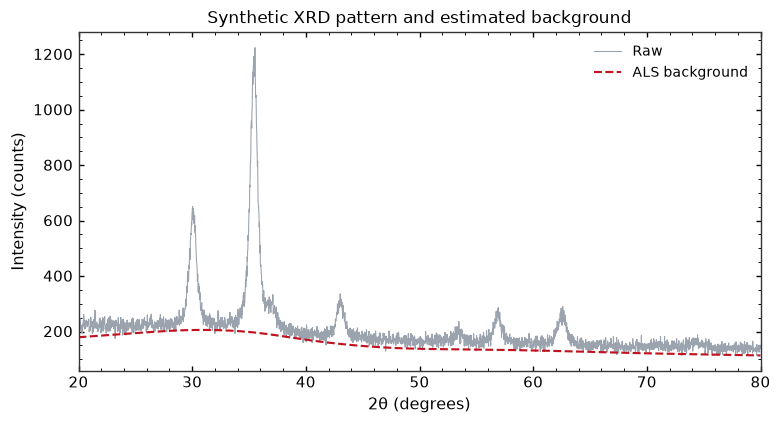

Background spans 114-206 counts
Strongest net peak: 1028 counts


In [5]:
xrd = frames["XRD"]
two_theta = xrd["two_theta_deg"].to_numpy(float)
counts = xrd["intensity_counts"].to_numpy(float)

background = an.baseline_als(counts, lam=1e7, p=0.001, n_iter=30)
net = counts - background

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(two_theta, counts, lw=0.7, color=cfg.COLORS["raw"], label="Raw")
ax.plot(two_theta, background, lw=1.4, ls="--", color=cfg.COLORS["accent"],
        label="ALS background")
ax.set_xlabel(r"2$\theta$ (degrees)"); ax.set_ylabel("Intensity (counts)")
ax.set_xlim(20, 80); ax.legend()
ax.set_title("Synthetic XRD pattern and estimated background")
plt.show()

print(f"Background spans {background.min():.0f}-{background.max():.0f} counts")
print(f"Strongest net peak: {net.max():.0f} counts")

### 4.2 Peak detection and indexing

For a cubic system, $d_{hkl} = a/\sqrt{h^2+k^2+l^2}$, and Bragg's law
$\lambda = 2d\sin\theta$ gives the expected positions. The reflection sequence
(220), (311), (400), (422), (511), (440) is the fingerprint of the inverse
spinel structure.

In [6]:
smooth = savgol_filter(np.clip(net, 0, None), 25, 3)

# Noise estimated on the SMOOTHED trace in a peak-free window. Using raw
# point-to-point scatter would over-estimate the threshold and lose the
# weak reflections.
quiet = (two_theta > 45) & (two_theta < 51)
sigma = float(np.std(smooth[quiet]))
found, _ = find_peaks(smooth, height=3*sigma, prominence=4.5*sigma, distance=17)

print(f"smoothed noise sigma = {sigma:.1f} counts")
print(f"{len(found)} candidate reflections detected\n")

rows = []
for h, k, l, i_rel in cfg.MAGNETITE_REFLECTIONS:
    pos = cfg.two_theta_from_hkl(h, k, l)
    d = cfg.A_MAGNETITE_ANG / np.sqrt(h*h + k*k + l*l)
    pos_mag = cfg.two_theta_from_hkl(h, k, l, a_ang=cfg.A_MAGHEMITE_ANG)
    dist = np.abs(two_theta[found] - pos)
    matched = bool(dist.min() <= 0.5) if len(found) else False
    rows.append({"hkl": f"({h}{k}{l})", "d_ang": round(d, 4),
                 "2theta_Fe3O4": round(pos, 3),
                 "2theta_gamma_Fe2O3": round(pos_mag, 3),
                 "shift_deg": round(pos_mag - pos, 3),
                 "I_rel_ref": i_rel, "detected": matched})

idx = pd.DataFrame(rows)
idx

smoothed noise sigma = 3.4 counts
11 candidate reflections detected



,hkl,d_ang,2theta_Fe3O4,2theta_gamma_Fe2O3,shift_deg,I_rel_ref,detected
0,(220),2.9684,30.080,30.265,0.185,30.0,True
1,(311),2.5315,35.431,35.650,0.219,100.0,True
2,(222),2.4237,37.062,37.292,0.230,8.0,False
3,(400),2.0990,43.059,43.330,0.271,20.0,True
4,(422),1.7138,53.418,53.764,0.346,10.0,True
5,(511),1.6158,56.944,57.316,0.373,30.0,True
6,(440),1.4842,62.530,62.947,0.417,40.0,True
7,(620),1.3275,70.937,71.427,0.490,4.0,False
8,(533),1.2804,73.972,74.490,0.518,10.0,True
9,(622),1.2657,74.973,75.500,0.527,4.0,False


Note the `shift_deg` column: switching from magnetite to
maghemite moves the reflections by only **0.2–0.5°**. That small a shift is
comparable to the errors introduced by specimen displacement or a zero offset
on a real diffractometer — which is exactly why XRD peak positions alone do
not settle the magnetite/maghemite question.

### 4.3 Profile fitting and the Scherrer equation

$$D = \frac{K\lambda}{\beta\cos\theta}$$

| Symbol | Meaning | Unit handling |
|--------|---------|---------------|
| $D$ | volume-weighted crystallite size | returned in nm |
| $K$ | shape factor, 0.9 for spheres | dimensionless |
| $\lambda$ | Cu K$\alpha_1$ wavelength | **0.154060 nm** (not Å) so $D$ is in nm |
| $\beta$ | sample broadening (FWHM) | **degrees → radians**; omitting this inflates $D$ by 57.3× |
| $\theta$ | Bragg angle | **$\theta = 2\theta/2$** |

Instrumental broadening is removed in quadrature:
$\beta_{sample} = \sqrt{\beta_{obs}^2 - \beta_{inst}^2}$.

In [7]:
# The full fitting routine lives in analysis.py; run it and load the results.
res = an.analyse_xrd()
fits = pd.read_csv(os.path.join(cfg.PROCESSED_DIR, "xrd_peak_analysis.csv"),
                   comment="#")
fits[["hkl", "two_theta_fit_deg", "d_spacing_ang", "fwhm_obs_deg",
      "fwhm_corrected_deg", "scherrer_size_nm", "i_rel_measured",
      "used_for_size"]]


[XRD] ------------------------------------------------------
  loaded 3001 points, 20.00-80.00 deg 2-theta
  detected 11 candidate reflections (smoothed noise sigma ~ 3.4 counts)
  indexed 7/11 expected Fe3O4 reflections
  lattice refinement uses 6/7 reflections (1 excluded: position uncertainty > 0.05 deg)
  fitted 7 reflections (min R^2 = 0.1799)
  Scherrer (mean of 5 strong peaks) = 11.12 +/- 0.46 nm
  Williamson-Hall: D = 11.94 nm, eps = 5.53e-04, R^2 = 0.2765
  Refined a = 8.3962 +/- 0.0073 A -> Fe3O4 (magnetite)


C:\Users\hafiz\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


    -> data/processed/xrd_processed.csv


    -> data/processed/xrd_peak_analysis.csv


    -> figures/fig01_xrd_raw.png/pdf


    -> figures/fig02_xrd_processed.png/pdf


    -> figures/fig03_xrd_indexed.png/pdf


    -> figures/fig04_xrd_peak_fit.png/pdf


    -> figures/fig05_williamson_hall.png/pdf


,hkl,two_theta_fit_deg,d_spacing_ang,fwhm_obs_deg,fwhm_corrected_deg,scherrer_size_nm,i_rel_measured,used_for_size
0,(220),30.0731,2.96914,0.73513,0.73076,11.26,42.8,True
1,(311),35.4384,2.53095,0.74197,0.73764,11.31,100.0,True
2,(400),43.0376,2.10002,0.76731,0.76313,11.19,13.9,True
3,(422),53.4335,1.71338,0.82360,0.81971,10.85,3.9,False
4,(511),56.8931,1.61713,0.78936,0.78530,11.51,11.2,True
5,(440),62.5421,1.48395,0.90300,0.89945,10.33,13.7,True
6,(533),74.2856,1.27575,1.07380,1.07082,9.31,2.9,False


In [8]:
# Verify the Scherrer arithmetic by hand for the strongest reflection,
# showing every unit conversion explicitly.
row = fits.loc[fits.hkl == "(311)"].iloc[0]

K      = 0.9
lam_nm = 0.154060
beta_deg = float(row["fwhm_corrected_deg"])
beta_rad = beta_deg * np.pi / 180.0          # degrees -> RADIANS
theta_deg = float(row["two_theta_fit_deg"]) / 2.0   # 2-theta -> theta
theta_rad = theta_deg * np.pi / 180.0

D = K * lam_nm / (beta_rad * np.cos(theta_rad))

print(f"beta  = {beta_deg:.4f} deg = {beta_rad:.6f} rad")
print(f"theta = {theta_deg:.4f} deg = {theta_rad:.6f} rad")
print(f"D     = {K} x {lam_nm} / ({beta_rad:.6f} x {np.cos(theta_rad):.6f})"
      f" = {D:.2f} nm")
print(f"pipeline value: {row['scherrer_size_nm']:.2f} nm")
print()
D_wrong = K * lam_nm / (beta_deg * np.cos(theta_rad))
print(f"If beta were left in DEGREES: {D_wrong:.4f} nm "
      f"-- wrong by a factor of {D/D_wrong:.1f}")

beta  = 0.7376 deg = 0.012874 rad
theta = 17.7192 deg = 0.309258 rad
D     = 0.9 x 0.15406 / (0.012874 x 0.952560) = 11.31 nm
pipeline value: 11.31 nm

If beta were left in DEGREES: 0.1973 nm -- wrong by a factor of 57.3


### 4.4 Williamson–Hall: separating size from strain

Scherrer attributes *all* broadening to size. If microstrain is present, that
biases the size low. Size and strain broadening scale differently with angle:

$$\beta\cos\theta = \frac{K\lambda}{D} + 4\varepsilon\sin\theta$$

so a plot of $\beta\cos\theta$ against $4\sin\theta$ gives the size from the
**intercept** and the strain from the **slope**.

In [9]:
strong = fits[fits.used_for_size]
th = np.radians(strong.two_theta_fit_deg / 2)
x = 4 * np.sin(th)
y = np.radians(strong.fwhm_corrected_deg) * np.cos(th)
w = 1.0 / np.radians(strong.fwhm_obs_err_deg.clip(lower=1e-5))

coef, cov = np.polyfit(x, y, 1, w=w, cov=True)
D_wh = cfg.SCHERRER_K * cfg.WAVELENGTH_NM / coef[1]

print(f"Scherrer, mean of strong peaks : {strong.scherrer_size_nm.mean():.2f} nm")
print(f"Williamson-Hall intercept      : D = {D_wh:.2f} nm")
print(f"Williamson-Hall slope          : eps = {coef[0]:.2e}")
print()
print(f"Injected ground truth          : D = {cfg.GROUND_TRUTH['xrd_crystallite_size_nm']} nm, "
      f"eps = {cfg.GROUND_TRUTH['xrd_microstrain']:.1e}")
print()
print("Scherrer UNDER-estimates because it absorbs the strain contribution")
print("into the size term. That is the physics, not a bug.")

Scherrer, mean of strong peaks : 11.12 nm
Williamson-Hall intercept      : D = 11.94 nm
Williamson-Hall slope          : eps = 5.53e-04

Injected ground truth          : D = 12.0 nm, eps = 8.0e-04

Scherrer UNDER-estimates because it absorbs the strain contribution
into the size term. That is the physics, not a bug.


### 4.5 XRD outcome

The analysis recovers the injected crystallite size to within a few percent
and the lattice parameter to within one standard error. The **microstrain is
the weakest recovery** — with only a handful of reflections over a limited
angular range, the Williamson–Hall *slope* is far less well constrained than
the *intercept*. It should be read as an order of magnitude (~10⁻⁴), not as a
precise value.

## 5. FTIR analysis

Band positions alone rarely justify a confident assignment. The workflow below
grades every detected band by confidence and explicitly declines to assign one
of them.

**Smoothing is chosen, not defaulted.** The narrowest genuine feature is about
9 cm⁻¹ wide; at 1 cm⁻¹ sampling an 11-point Savitzky–Golay filter stays well
below that, so band shapes and areas survive. Smoothing wide enough to look
attractive is usually wide enough to distort what you are measuring.

In [10]:
ftir_res = an.analyse_ftir()
peaks_tbl = pd.read_csv(os.path.join(cfg.PROCESSED_DIR,
                                     "ftir_peak_assignments.csv"), comment="#")
peaks_tbl[["peak_wavenumber_cm_1", "peak_absorbance_au", "assignment",
           "confidence"]]


[FTIR] -----------------------------------------------------
  loaded 3601 points, 4000-400 cm-1
  detected 6 bands (noise sigma = 0.00634 A)
    absent : goethite_alpha_FeOOH_890_cm-1
    absent : goethite_alpha_FeOOH_795_cm-1
    absent : organic_C-H_stretch_2850_2960_cm-1
    absent : carboxylate_C=O_1700_cm-1
    absent : nitrate_1384_cm-1
    absent : sulfate_1100_cm-1
    -> data/processed/ftir_processed.csv
    -> data/processed/ftir_peak_assignments.csv


C:\Users\hafiz\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


    -> figures/fig06_ftir_raw.png/pdf


    -> figures/fig07_ftir_processed.png/pdf


    -> figures/fig08_ftir_labelled.png/pdf


,peak_wavenumber_cm_1,peak_absorbance_au,assignment,confidence
0,3394.0,0.26922,O-H stretch: adsorbed molecular water + surfac...,high
1,2341.0,0.05769,Atmospheric CO2 asymmetric stretch -- INSTRUME...,high
2,1629.0,0.13063,H-O-H bending of molecular water,high
3,1046.0,0.05226,Tentative: Fe-OH deformation / surface hydroxyl,low
4,571.0,0.45683,"Fe-O stretch, tetrahedrally coordinated Fe",high
5,446.0,0.20650,"Fe-O stretch, octahedrally coordinated Fe",medium


In [11]:
for _, r in peaks_tbl.iterrows():
    print(f"{r['peak_wavenumber_cm_1']:7.1f} cm-1  [{r['confidence']:>6s}]  "
          f"{r['assignment']}")
    print(f"{'':16s}{r['interpretation_note']}")
    print()

 3394.0 cm-1  [  high]  O-H stretch: adsorbed molecular water + surface hydroxyls
                Very broad -> extensive hydrogen bonding. Cannot distinguish H2O from structural OH on band position alone.

 2341.0 cm-1  [  high]  Atmospheric CO2 asymmetric stretch -- INSTRUMENT ARTEFACT
                Not a sample feature. Arises from incomplete background compensation of ambient CO2.

 1629.0 cm-1  [  high]  H-O-H bending of molecular water
                Co-occurrence with the 3400 band supports molecular water rather than isolated OH groups.

 1046.0 cm-1  [   low]  Tentative: Fe-OH deformation / surface hydroxyl
                Weak and broad. Overlaps the region where residual sulfate or silicate would also absorb. NOT a confident assignment.

  571.0 cm-1  [  high]  Fe-O stretch, tetrahedrally coordinated Fe
                Principal spinel lattice mode. Position is phase-sensitive but NOT sufficient alone to separate Fe3O4 from gamma-Fe2O3.

  446.0 cm-1  [medium]  Fe-O stret

### 5.1 Evidence from absence

Bands that are *not* present carry information — but absence has to be tested
properly. Asking whether absorbance is merely low in a window fails, because
the tail of a strong neighbouring band leaks into it (the 1630 cm⁻¹ water bend
bleeds into the carbonyl region). The defensible test is whether a **resolved
local maximum** exists there.

In [12]:
for name, absent in ftir_res["absence_checks"].items():
    print(f"{'ABSENT ' if absent else 'PRESENT'}  {name}")

print()
print("No C-H or C=O bands -> consistent with the uncoated-surface assumption")
print("and with the absence of an organic step in the TGA data.")
print("These are consistency checks, not proof: FTIR could miss a few percent")
print("of a trace phase without showing a resolved band.")

ABSENT   goethite_alpha_FeOOH_890_cm-1
ABSENT   goethite_alpha_FeOOH_795_cm-1
ABSENT   organic_C-H_stretch_2850_2960_cm-1
ABSENT   carboxylate_C=O_1700_cm-1
ABSENT   nitrate_1384_cm-1
ABSENT   sulfate_1100_cm-1

No C-H or C=O bands -> consistent with the uncoated-surface assumption
and with the absence of an organic step in the TGA data.
These are consistency checks, not proof: FTIR could miss a few percent
of a trace phase without showing a resolved band.


## 6. UV–Vis analysis

This section reaches a **negative result**, deliberately.

Two problems arise before any modelling:

1. **Photometric range.** Absorbance above ~2.5 is dominated by stray light on
   a conventional spectrophotometer. Those points are flagged and excluded.
2. **Scattering.** For a *dispersion*, the instrument records attenuation =
   absorption + turbidity. An empirical $\lambda^{-n}$ term is fitted at long
   wavelengths and subtracted.

In [13]:
uv_res = an.analyse_uvvis()

print(f"Points above the photometric limit : {uv_res['n_points_above_limit']}")
print(f"Reliable only above               : {uv_res['reliable_above_nm']:.0f} nm")
print(f"Effective turbidity exponent n    : {uv_res['scattering_exponent_n_effective']:.2f}")
print(f"Scattering share of A at 600 nm   : "
      f"{100*uv_res['scattering_fraction_at_600nm']:.0f} %")
print()
print(uv_res["absorption_character"])


[UV-Vis] ---------------------------------------------------
  loaded 701 points, 200-900 nm
  107 points exceed A = 2.5 (photometrically unreliable below 307 nm)
  empirical turbidity power law: A ~ lambda^-2.02 (log-log R^2 = 0.9960); effective exponent, not a pure scattering law


  Tauc extrapolations span 0.66-3.00 eV (spread 2.34 eV) across 4 model choices
  including linear-window choice, the full defensible span is 0.64-3.00 eV (2.37 eV)
    -> data/processed/uvvis_processed.csv


    -> figures/fig09_uvvis_spectrum.png/pdf


    -> figures/fig10_tauc_demonstration.png/pdf
Points above the photometric limit : 107
Reliable only above               : 307 nm
Effective turbidity exponent n    : 2.02
Scattering share of A at 600 nm   : 93 %

Broad, monotonically rising absorption from the NIR into the UV with no discrete excitonic maximum -- consistent with O(2p)->Fe(3d) charge transfer plus a strong sub-edge (Urbach) tail. This is why magnetite appears black.


### 6.1 Tauc analysis — demonstrated, then *not* reported

$$(\alpha h\nu)^{1/r} = B\,(h\nu - E_g)$$

with $r = \tfrac12$ (direct allowed) or $r = 2$ (indirect allowed).

Three reasons this cannot yield a band gap here:

1. **Wrong material.** Fe₃O₄ is a mixed-valence, near-metallic conductor above
   the Verwey transition — not a wide-gap semiconductor. The Tauc relation was
   derived for amorphous semiconductors.
2. **Wrong quantity.** Tauc needs the absorption coefficient α. We have the
   absorbance of a dispersion, which conflates absorption with scattering.
3. **Unstable answer.** Quantified below.

In [14]:
rows = []
for key, v in uv_res["tauc_results"].items():
    base, trans = key.split("__")
    rows.append({"baseline": base.replace("_", " "),
                 "transition": trans.replace("_", " "),
                 "apparent_Eg_eV": v["Eg_eV"],
                 "fit_R2": v["r2"],
                 "window_eV": f"{v['window_eV'][0]:.2f}-{v['window_eV'][1]:.2f}"})
tauc_df = pd.DataFrame(rows)
display(tauc_df)

lo, hi = uv_res["tauc_full_defensible_range_eV"]
print(f"\nEvery fit has R2 >= {tauc_df.fit_R2.min():.3f} -- they ALL look excellent.")
print(f"Yet the values span {tauc_df.apparent_Eg_eV.min():.2f}-"
      f"{tauc_df.apparent_Eg_eV.max():.2f} eV.")
print(f"Including the choice of linear window: {lo:.2f}-{hi:.2f} eV "
      f"({hi-lo:.2f} eV wide).")
print()
print("CONCLUSION: no band gap is reported from these data.")

,baseline,transition,apparent_Eg_eV,fit_R2,window_eV
0,uncorrected,direct allowed,2.226,0.99287,2.44-2.64
1,uncorrected,indirect allowed,0.661,0.99990,1.86-2.17
2,scattering corrected,direct allowed,3.003,0.97576,3.07-3.39
3,scattering corrected,indirect allowed,2.373,0.99984,3.07-3.39



Every fit has R2 >= 0.976 -- they ALL look excellent.
Yet the values span 0.66-3.00 eV.
Including the choice of linear window: 0.64-3.00 eV (2.36 eV wide).

CONCLUSION: no band gap is reported from these data.


A spread of that size is larger than any difference such an
analysis would be trying to resolve. Reporting a single value and quoting its
excellent R² would be indefensible — yet it is common in the literature.
**Knowing which numbers not to report is part of analytical competence.**

## 7. SEM-based particle-size analysis

**No micrograph is fabricated.** What is analysed is the measurement table an
analyst obtains *after* segmenting a real micrograph (e.g. in ImageJ/Fiji) —
the numeric input to the statistical workflow being demonstrated.

In [15]:
sem = frames["SEM"]
d = sem["equivalent_diameter_nm"].to_numpy(float)
sem.head(10)

,particle_id,equivalent_diameter_nm,aspect_ratio,circularity
0,P001,18.34,1.104,0.935
1,P002,27.74,1.183,0.914
2,P003,21.71,1.121,0.945
3,P004,27.33,1.151,0.874
4,P005,17.82,1.055,0.958
5,P006,23.39,1.088,0.871
6,P007,16.08,1.000,0.990
7,P008,24.69,1.108,0.923
8,P009,22.24,1.206,0.915
9,P010,18.81,1.032,0.959


In [16]:
desc = sem["equivalent_diameter_nm"].describe()
q1, med, q3 = np.percentile(d, [25, 50, 75])

print(f"n                  {len(d)}")
print(f"mean               {d.mean():.2f} nm")
print(f"median             {med:.2f} nm")
print(f"std dev            {d.std(ddof=1):.2f} nm")
print(f"std error          {d.std(ddof=1)/np.sqrt(len(d)):.3f} nm")
print(f"min / max          {d.min():.2f} / {d.max():.2f} nm")
print(f"Q1 / Q3            {q1:.2f} / {q3:.2f} nm")
print(f"IQR                {q3-q1:.2f} nm")
print(f"CV                 {100*d.std(ddof=1)/d.mean():.1f} %")
print(f"skewness           {stats.skew(d):.3f}  (right-skewed)")

n                  84
mean               19.13 nm
median             18.74 nm
std dev            4.19 nm
std error          0.457 nm
min / max          10.72 / 31.53 nm
Q1 / Q3            16.24 / 21.48 nm
IQR                5.25 nm
CV                 21.9 %
skewness           0.478  (right-skewed)


### 7.1 Distribution shape, and the limits of n = 84

In [17]:
shape, loc, scale = stats.lognorm.fit(d, floc=0)
ks_ln = stats.kstest(d, "lognorm", args=(shape, loc, scale))
mu_n, sd_n = stats.norm.fit(d)
ks_no = stats.kstest(d, "norm", args=(mu_n, sd_n))

print(f"lognormal: median = {scale:.2f} nm, GSD = {np.exp(shape):.3f}, "
      f"KS p = {ks_ln.pvalue:.3f}")
print(f"normal   : mean   = {mu_n:.2f} nm, SD  = {sd_n:.3f}, "
      f"KS p = {ks_no.pvalue:.3f}")
print()
print("Neither model is rejected. With n = 84 these data CANNOT distinguish")
print("lognormal from normal. The lognormal fit is reported because particle")
print("formation physics motivates it -- NOT because these data demonstrate it.")
print("Treating a non-significant KS test as proof of a distribution is a")
print("misuse of the test.")

lognormal: median = 18.68 nm, GSD = 1.245, KS p = 0.755
normal   : mean   = 19.13 nm, SD  = 4.161, KS p = 0.842

Neither model is rejected. With n = 84 these data CANNOT distinguish
lognormal from normal. The lognormal fit is reported because particle
formation physics motivates it -- NOT because these data demonstrate it.
Treating a non-significant KS test as proof of a distribution is a
misuse of the test.


### 7.2 Number vs volume weighting

A plain mean of diameters is *number-weighted*. XRD, scattering and
sedimentation all weight toward larger particles. The moment means are

$$D_{[4,3]} = \frac{\sum d^4}{\sum d^3} \quad\text{(volume-weighted)}
\qquad
D_{[3,2]} = \frac{\sum d^3}{\sum d^2} \quad\text{(surface-weighted)}$$

Comparing a number-weighted SEM mean directly against a volume-weighted XRD
size compares two different statistics of two different quantities.

In [18]:
d43 = (d**4).sum() / (d**3).sum()
d32 = (d**3).sum() / (d**2).sum()

rng = np.random.default_rng(cfg.RANDOM_SEED)
boot = rng.choice(d, size=(10000, len(d)), replace=True).mean(axis=1)
ci = np.percentile(boot, [2.5, 97.5])

print(f"number mean        D      = {d.mean():.2f} nm")
print(f"surface-weighted   D[3,2] = {d32:.2f} nm")
print(f"volume-weighted    D[4,3] = {d43:.2f} nm")
print(f"\n95% bootstrap CI on the mean: {ci[0]:.2f} - {ci[1]:.2f} nm")

number mean        D      = 19.13 nm
surface-weighted   D[3,2] = 20.95 nm
volume-weighted    D[4,3] = 21.87 nm

95% bootstrap CI on the mean: 18.24 - 20.05 nm



[SEM] ------------------------------------------------------
  loaded 84 particle measurements
  lognormal fit: median = 18.68 nm, GSD = 1.245, KS p = 0.755
  normal fit comparison: KS p = 0.842
    -> data/processed/sem_size_statistics.csv
    -> data/processed/sem_size_distribution.csv


    -> figures/fig11_sem_histogram.png/pdf


    -> figures/fig12_sem_boxplot.png/pdf


    -> figures/fig13_sem_size_distribution.png/pdf


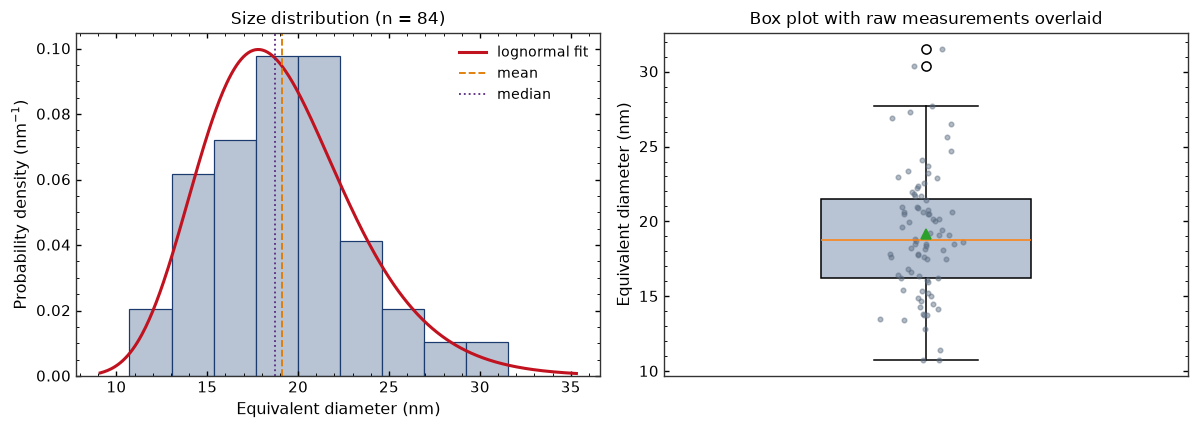

In [19]:
sem_res = an.analyse_sem()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(d, bins="fd", density=True, color="#B8C4D4",
             edgecolor=cfg.COLORS["processed"], lw=0.8)
xs = np.linspace(d.min()*0.85, d.max()*1.12, 400)
axes[0].plot(xs, stats.lognorm.pdf(xs, shape, loc, scale),
             color=cfg.COLORS["accent"], lw=2, label="lognormal fit")
axes[0].axvline(d.mean(), ls="--", color=cfg.COLORS["fit"], label="mean")
axes[0].axvline(med, ls=":", color=cfg.COLORS["highlight"], label="median")
axes[0].set_xlabel("Equivalent diameter (nm)")
axes[0].set_ylabel("Probability density (nm$^{-1}$)")
axes[0].legend(); axes[0].set_title(f"Size distribution (n = {len(d)})")

bp = axes[1].boxplot(d, widths=0.4, patch_artist=True, showmeans=True)
bp["boxes"][0].set_facecolor("#B8C4D4")
axes[1].plot(np.random.default_rng(7).normal(1, 0.035, len(d)), d, "o",
             ms=3, color="#5A6B80", alpha=0.45)
axes[1].set_ylabel("Equivalent diameter (nm)"); axes[1].set_xticks([])
axes[1].set_title("Box plot with raw measurements overlaid")
plt.tight_layout(); plt.show()

## 8. TGA analysis

DTG $= -\mathrm{d}m/\mathrm{d}T$ is computed analytically from the local
Savitzky–Golay polynomial rather than by finite differences — differentiation
amplifies noise, and an under-smoothed DTG trace invents maxima that are not
there. A wider window is used for the derivative than for the mass curve.

In [20]:
tga_res = an.analyse_tga()
regions = pd.read_csv(os.path.join(cfg.PROCESSED_DIR,
                                   "tga_mass_loss_regions.csv"), comment="#")
regions[["region", "T_start_C", "T_end_C", "mass_loss_percent",
         "fraction_of_total_loss_percent", "dtg_max_temperature_C",
         "assignment_confidence"]]


[TGA] ------------------------------------------------------
  loaded 1551 points, 25-800 C
  DTG maxima at: [79.0, 238.5, 519.0] C (noise = 5.93e-05 %/C)
    Region I    25-150 C :  2.49 %  (53.5 % of total)
   Region II   150-400 C :  1.56 %  (33.6 % of total)
  Region III   400-650 C :  0.59 %  (12.7 % of total)
   Region IV   650-800 C :  0.01 %  ( 0.3 % of total)
  step deconvolution (boundary-independent):
    step at   78.0 C :  2.60 % (width 21.1 C)
    step at  243.1 C :  1.70 % (width 43.9 C)
    step at  521.8 C :  0.60 % (width 38.1 C)
  implied Region II water coverage = 5.37 molecules/nm^2 (SSA = 97 m2/g from XRD size)
    -> data/processed/tga_processed.csv
    -> data/processed/tga_mass_loss_regions.csv


    -> figures/fig14_tga_curve.png/pdf


    -> figures/fig15_dtg_curve.png/pdf


    -> figures/fig16_tga_dtg_combined.png/pdf


,region,T_start_C,T_end_C,mass_loss_percent,fraction_of_total_loss_percent,dtg_max_temperature_C,assignment_confidence
0,Region I,25.0,150.0,2.489,53.5,79.0,high
1,Region II,150.0,400.0,1.561,33.6,238.5,medium
2,Region III,400.0,650.0,0.589,12.7,519.0,low
3,Region IV,650.0,800.0,0.012,0.3,651.0,high


### 8.1 Region integration vs step deconvolution

Region-based integration depends on where the analyst draws the boundaries,
and adjacent events overlap across them. Fitting the whole curve as a sum of
logistic steps plus a linear drift removes that arbitrariness and returns the
amplitude of each **event** rather than of each temperature **interval**.

In [21]:
dec = tga_res["step_deconvolution"]
print(f"converged: {dec['converged']},  R2 = {dec['r_squared']:.5f}\n")

gt = [cfg.GROUND_TRUTH[k] for k in
      ("tga_step1_pct", "tga_step2_pct", "tga_step3_pct")]
for i, (s, truth) in enumerate(zip(dec["steps"], gt), start=1):
    print(f"step {i}: {s['amplitude_percent']:.2f} +/- "
          f"{s['amplitude_err_percent']:.2f} %  at {s['midpoint_C']:.1f} C   "
          f"(injected {truth:.2f} %)")

print(f"\nSummed amplitude      : {dec['summed_amplitude_percent']:.2f} %")
print(f"Measured total loss   : {tga_res['total_mass_loss_percent']:.2f} %")
print("\nThe sum exceeds the measured loss because part of the lowest-")
print("temperature event happens BEFORE the run reaches 25 C -- a real effect")
print("that makes TGA under-report total volatile content.")

converged: True,  R2 = 1.00000

step 1: 2.60 +/- 0.00 %  at 78.0 C   (injected 2.60 %)
step 2: 1.70 +/- 0.00 %  at 243.1 C   (injected 1.70 %)
step 3: 0.60 +/- 0.00 %  at 521.8 C   (injected 0.60 %)

Summed amplitude      : 4.90 %
Measured total loss   : 4.65 %

The sum exceeds the measured loss because part of the lowest-
temperature event happens BEFORE the run reaches 25 C -- a real effect
that makes TGA under-report total volatile content.


### 8.2 Combining TGA with XRD: surface water coverage

Treating the crystallites as spheres of the Williamson–Hall diameter gives a
specific surface area; the Region II mass loss then converts to an areal water
density. This is a genuine cross-technique result — neither technique could
produce it alone.

In [22]:
D_nm = res["williamson_hall_size_nm"]
rho = 5.17                      # g/cm3, magnetite
ssa = 6.0 / (rho * D_nm * 1e-7) / 1e4      # m2/g
region_ii = regions.loc[regions.region == "Region II",
                        "mass_loss_percent"].iloc[0]

molecules = (region_ii / 100.0) / 18.015 * 6.02214076e23   # per gram
coverage = molecules / (ssa * 1e18)

print(f"XRD crystallite size      : {D_nm:.2f} nm")
print(f"Implied specific surface  : {ssa:.0f} m2/g  (spheres)")
print(f"Region II mass loss       : {region_ii:.2f} %")
print(f"-> surface water coverage : {coverage:.2f} molecules/nm2")
print()
print("Typical hydroxylated iron-oxide surfaces: ~2-12 /nm2.")
print("The datasets are mutually consistent. Note this inherits the")
print("sphericity assumption and ignores porosity and agglomeration.")

XRD crystallite size      : 11.94 nm
Implied specific surface  : 97 m2/g  (spheres)
Region II mass loss       : 1.56 %
-> surface water coverage : 5.37 molecules/nm2

Typical hydroxylated iron-oxide surfaces: ~2-12 /nm2.
The datasets are mutually consistent. Note this inherits the
sphericity assumption and ignores porosity and agglomeration.


### 8.3 Why atmosphere is not a footnote

The inert atmosphere here is an **assumption**. In air, Fe₃O₄ oxidises to
γ-Fe₂O₃ and then α-Fe₂O₃ above ~200 °C, a mass **gain** of up to **+3.45 %**
that would partly cancel the losses — a genuinely hydrated sample could look
nearly anhydrous. A TGA result reported without its atmosphere, heating rate
and sample mass is uninterpretable.

## 9. Cross-technique comparison

In [23]:
cross = an.cross_technique_synthesis()
matrix = pd.read_csv(os.path.join(cfg.PROCESSED_DIR,
                                  "technique_comparison_matrix.csv"),
                     comment="#")
pd.set_option("display.max_colwidth", 70)
matrix[["technique", "main_information", "quantitative_output",
        "key_limitation"]]


[Cross-technique] ------------------------------------------
    -> data/processed/technique_comparison_matrix.csv
  SEM/XRD size ratio: 1.60 (number-weighted), 1.83 (volume-weighted)
    -> data/processed/cross_technique_summary.csv


    -> figures/fig17_size_comparison.png/pdf


    -> figures/fig18_summary_dashboard.png/pdf


,technique,main_information,quantitative_output,key_limitation
0,XRD,"Crystal structure, phase identity, lattice parameter, crystallite ...",d-spacings; a = lattice parameter (A); D_Scherrer (nm); microstrai...,Volume-weighted and blind to amorphous or poorly-ordered material;...
1,FTIR,Fe-O lattice modes; adsorbed water; surface hydroxyls; presence/ab...,Band positions (cm-1); relative intensities; band areas (semi-quan...,Heavily overlapped bands in the Fe-O region; absorptivities are un...
2,UV-Vis,Charge-transfer absorption; qualitative optical behaviour; dispers...,Absorbance vs wavelength; apparent Tauc intercepts (unreliable for...,"For a dispersion, measured absorbance mixes true absorption with M..."
3,SEM,"Particle/aggregate size, shape, degree of agglomeration, surface t...","Size distribution statistics: mean, median, SD, quartiles, D[4,3],...","Measures whole features, so aggregates are counted as particles; t..."
4,TGA,"Volatile content: adsorbed water, surface hydroxyls, organics (if ...",Mass loss per region (%); DTG peak temperatures (C); total volatil...,"Gives mass change only, never chemical identity; results depend st..."


### 9.1 Why XRD and SEM sizes disagree

This is the most informative single result in the project. The two numbers
differ — and that is the expected outcome of measuring different quantities
with different statistical weightings, not a discrepancy to explain away.

In [24]:
cmp = cross["size_comparison"]
print(f"XRD Scherrer (mean)        : {cmp['xrd_scherrer_mean_nm']:.2f} nm")
print(f"XRD Williamson-Hall        : {cmp['xrd_williamson_hall_nm']:.2f} nm")
print(f"SEM number mean            : {cmp['sem_number_mean_nm']:.2f} nm")
print(f"SEM volume-weighted D[4,3] : {cmp['sem_volume_weighted_D43_nm']:.2f} nm")
print()
print(f"ratio (number-weighted)    : {cmp['ratio_sem_number_to_xrd']:.2f}")
print(f"ratio (volume-weighted)    : {cmp['ratio_sem_volume_to_xrd']:.2f}")
print()
for i, reason in enumerate(cmp["reasons_for_divergence"], start=1):
    print(f"{i}. {reason}\n")

XRD Scherrer (mean)        : 11.12 nm
XRD Williamson-Hall        : 11.94 nm
SEM number mean            : 19.13 nm
SEM volume-weighted D[4,3] : 21.87 nm

ratio (number-weighted)    : 1.60
ratio (volume-weighted)    : 1.83

1. Different measurands: XRD reports the size of coherently diffracting domains; SEM reports the outline of a visible feature. A single SEM feature may contain several domains.

2. Different weightings: Scherrer sizes are volume-weighted while a raw SEM mean is number-weighted. Volume weighting emphasises the largest particles, so the two statistics are not comparable until one is converted (here D[4,3]).

3. Surface disorder: a structurally disordered or hydrated surface shell contributes to the SEM outline but diffracts incoherently, so XRD does not count it.

4. Agglomeration: touching particles are frequently segmented as one feature, inflating the SEM size.

5. Microstrain: if strain broadening is attributed entirely to size, the Scherrer size is systematically U

## 10. Summary of demonstration outcomes

In [25]:
with open(os.path.join(cfg.REPORT_DIR, "analysis_results.json"),
          encoding="utf-8") as fh:
    R = json.load(fh)

X, S_, T_, U_ = R["xrd"], R["sem"], R["tga"], R["uvvis"]
rows = [
    ("XRD", "Phase assignment", X["phase_assignment"]),
    ("XRD", "Lattice parameter",
     f"{X['lattice_parameter_ang']:.4f} +/- {X['lattice_parameter_err_ang']:.4f} A"),
    ("XRD", "Crystallite size (Scherrer)",
     f"{X['scherrer_mean_nm']:.2f} +/- {X['scherrer_sd_nm']:.2f} nm"),
    ("XRD", "Crystallite size (W-H)",
     f"{X['williamson_hall_size_nm']:.2f} +/- {X['williamson_hall_size_err_nm']:.2f} nm"),
    ("XRD", "Microstrain (order of magnitude)",
     f"~{X['williamson_hall_microstrain']:.0e}"),
    ("FTIR", "Bands resolved", f"{R['ftir']['n_bands_detected']}"),
    ("FTIR", "Organic bands", "none detected (uncoated surface)"),
    ("UV-Vis", "Optical band gap", "NOT REPORTED - see section 6"),
    ("UV-Vis", "Tauc spread across defensible choices",
     f"{U_['tauc_full_defensible_range_eV'][0]:.2f}-"
     f"{U_['tauc_full_defensible_range_eV'][1]:.2f} eV"),
    ("SEM", "Number mean diameter",
     f"{S_['mean_nm']:.2f} nm (n = {S_['n']})"),
    ("SEM", "Volume-weighted D[4,3]",
     f"{S_['volume_weighted_D43_nm']:.2f} nm"),
    ("TGA", "Total mass loss", f"{T_['total_mass_loss_percent']:.2f} %"),
    ("TGA", "Events resolved",
     ", ".join(f"{p['temperature_C']:.0f} C" for p in T_["dtg_peaks"])),
    ("Cross", "SEM / XRD size ratio",
     f"{cmp['ratio_sem_number_to_xrd']:.2f} (number), "
     f"{cmp['ratio_sem_volume_to_xrd']:.2f} (volume)"),
]
pd.DataFrame(rows, columns=["Technique", "Quantity", "Demonstration outcome"])

,Technique,Quantity,Demonstration outcome
0,XRD,Phase assignment,Fe3O4 (magnetite)
1,XRD,Lattice parameter,8.3962 +/- 0.0073 A
2,XRD,Crystallite size (Scherrer),11.12 +/- 0.46 nm
3,XRD,Crystallite size (W-H),11.94 +/- 0.59 nm
4,XRD,Microstrain (order of magnitude),~6e-04
5,FTIR,Bands resolved,6
6,FTIR,Organic bands,none detected (uncoated surface)
7,UV-Vis,Optical band gap,NOT REPORTED - see section 6
8,UV-Vis,Tauc spread across defensible choices,0.64-3.00 eV
9,SEM,Number mean diameter,19.13 nm (n = 84)


### 10.1 Pipeline validation

Because the generative parameters are known, the analysis can be checked
against them — impossible with real data. `scripts/validate.py` runs 55
automated checks across parameter recovery, unit/arithmetic consistency and
synthetic-data integrity.

In [26]:
gtv = cfg.GROUND_TRUTH
checks = [
    ("Crystallite size (W-H)", f"{gtv['xrd_crystallite_size_nm']:.2f} nm",
     f"{X['williamson_hall_size_nm']:.2f} nm"),
    ("Lattice parameter", f"{gtv['xrd_lattice_parameter_ang']:.4f} A",
     f"{X['lattice_parameter_ang']:.4f} A"),
    ("Microstrain", f"{gtv['xrd_microstrain']:.1e}",
     f"{X['williamson_hall_microstrain']:.1e}"),
    ("SEM lognormal median", f"{gtv['sem_lognormal_median_nm']:.2f} nm",
     f"{S_['lognormal_median_nm']:.2f} nm"),
    ("SEM geometric SD", f"{gtv['sem_lognormal_gsd']:.3f}",
     f"{S_['lognormal_gsd']:.3f}"),
    ("TGA step 1", f"{gtv['tga_step1_pct']:.2f} %",
     f"{T_['step_deconvolution']['steps'][0]['amplitude_percent']:.2f} %"),
    ("TGA step 2", f"{gtv['tga_step2_pct']:.2f} %",
     f"{T_['step_deconvolution']['steps'][1]['amplitude_percent']:.2f} %"),
    ("TGA step 3", f"{gtv['tga_step3_pct']:.2f} %",
     f"{T_['step_deconvolution']['steps'][2]['amplitude_percent']:.2f} %"),
]
pd.DataFrame(checks, columns=["Quantity", "Injected", "Recovered"])

,Quantity,Injected,Recovered
0,Crystallite size (W-H),12.00 nm,11.94 nm
1,Lattice parameter,8.3960 A,8.3962 A
2,Microstrain,8.0e-04,5.5e-04
3,SEM lognormal median,18.50 nm,18.68 nm
4,SEM geometric SD,1.280,1.245
5,TGA step 1,2.60 %,2.60 %
6,TGA step 2,1.70 %,1.70 %
7,TGA step 3,0.60 %,0.60 %


## 11. Limitations

### 11.1 The overriding limitation

**These data are synthetic.** They contain exactly the physics the generative
models encode and no more. Real specimens bring preferred orientation,
anisotropic crystallite shapes, stacking faults, amorphous fractions invisible
to diffraction, inhomogeneity between aliquots, instrument drift and
preparation artefacts. **Nothing here is evidence about any real material.**

### 11.2 Method-specific limitations

| Method | Limitation |
|--------|-----------|
| Scherrer | Gives a **volume-weighted coherent-domain size**, not a particle size. Assumes strain-free crystallites unless corrected; *K* is uncertain at the ±10 % level; unreliable above ~100 nm. |
| Single-peak fitting | Rietveld refinement of the full pattern would constrain parameters better; single-peak methods were used here to show them explicitly. |
| Kα₂ | The pattern was generated for a single wavelength. Real lab data contain the doublet, which must be stripped before width analysis. |
| FTIR | Band intensities are not concentrations without absorptivities. ATR and KBr give different relative intensities and positions. |
| Band overlap | The Fe–O region is congested and shifts with size, oxidation state and sampling geometry — FTIR cannot settle magnetite vs maghemite. |
| UV–Vis | Dispersion optics conflate absorption with scattering; no band gap is reportable for this material. |
| SEM statistics | n = 84 constrains the mean but not the distribution shape or tails; agglomeration, thresholding, sampling bias and coating all bias sizes upward. |
| TGA | Measures mass only, never identity. Depends on atmosphere, heating rate, sample mass and packing — all assumed here. |

### 11.3 What this notebook *does* establish

That the author can build a reproducible analytical pipeline, apply
established physical relations with correct unit handling, quantify
uncertainty, validate results against known inputs, distinguish signal from
artefact, grade confidence in interpretations — and decline to report a number
when the data do not support one.

---

*End of notebook. Generated from `scripts/make_notebook.py`; all analysis
functions live in `scripts/analysis.py`.*